# 02 · Feature Engineering — NASA CMAPSS FD004

Starting from 19 live sensors, this notebook builds and validates the feature set used for XGBoost RUL regression.

| Section | Purpose |
|---|---|
| 1. Sensor Selection | Drop ambient/demand signals and near-perfect duplicates. Justify every drop with evidence from EDA. |
| 2. Condition Normalisation | Fit KMeans + per-cluster z-score on FD004 train. Verify altitude effect is removed. |
| 3. Feature Engineering | Rolling window statistics, degradation rate, cycle fraction |
| 4. Feature Validation | Pearson r and Mutual Information vs RUL for every feature |
| 5. PCA Comparison | Raw vs normalised vs engineered — does engineering concentrate signal? |
| 6. Walk-Forward Ridge CV | Confirm the feature set carries genuine predictive signal |
| 7. Final Feature Set | Lock in the feature list used for Phase 3 XGBoost training |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.float_format', '{:.4f}'.format)

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')
MODELS    = Path('../models')
for p in [PROCESSED, MODELS / 'preprocessing']:
    p.mkdir(parents=True, exist_ok=True)

COLS = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
RUL_CAP = 130

def load_raw(fd_id, split='train'):
    df = pd.read_csv(RAW / f'{split}_FD00{fd_id}.txt',
                     sep=r'\s+', header=None, names=COLS)
    df['dataset'] = f'FD00{fd_id}'
    return df

fd4_train = load_raw(4, 'train')
fd4_test  = load_raw(4, 'test')
fd2_train = load_raw(2, 'train')  # loaded for in-notebook comparison only — not saved to processed

print(f"FD004 train: {fd4_train.shape} — {fd4_train.unit.nunique()} engines")
print(f"FD004 test:  {fd4_test.shape}  — {fd4_test.unit.nunique()} engines")
print(f"FD002 train: {fd2_train.shape} — {fd2_train.unit.nunique()} engines (comparison only)")

SENSOR_NAMES = {
    's1':  'Fan inlet temperature (°R)',
    's2':  'Low-pressure compressor outlet temperature (°R)',
    's3':  'High-pressure compressor outlet temperature (°R)',
    's4':  'Low-pressure turbine outlet temperature (°R)',
    's5':  'Fan inlet pressure (psia)',
    's6':  'Bypass duct pressure (psia)',
    's7':  'High-pressure compressor outlet pressure (psia)',
    's8':  'Physical fan speed (rpm)',
    's9':  'Physical core speed (rpm)',
    's10': 'Engine pressure ratio',
    's11': 'High-pressure compressor static pressure (psia)',
    's12': 'Fuel-to-air ratio',
    's13': 'Corrected fan speed (rpm)',
    's14': 'Corrected core speed (rpm)',
    's15': 'Bypass ratio',
    's16': 'Burner fuel-air ratio',
    's17': 'Bleed air enthalpy (BTU/lb)',
    's18': 'Commanded fan speed (rpm)',
    's19': 'Commanded corrected fan speed (rpm)',
    's20': 'High-pressure turbine coolant bleed flow (lbm/s)',
    's21': 'Low-pressure turbine coolant bleed flow (lbm/s)',
}
SENSOR_SHORT = {
    's1':  'Fan inlet temp',
    's2':  'LP compressor outlet temp',
    's3':  'HP compressor outlet temp',
    's4':  'LP turbine outlet temp',
    's5':  'Fan inlet pressure',
    's6':  'Bypass duct pressure',
    's7':  'HP compressor outlet pressure',
    's8':  'Fan speed',
    's9':  'Core speed',
    's10': 'Pressure ratio',
    's11': 'HP compressor static pressure',
    's12': 'Fuel-air ratio',
    's13': 'Corrected fan speed',
    's14': 'Corrected core speed',
    's15': 'Bypass ratio',
    's16': 'Burner fuel-air ratio',
    's17': 'Bleed air enthalpy',
    's18': 'Commanded fan speed',
    's19': 'Cmd corrected fan speed',
    's20': 'HP turbine coolant flow',
    's21': 'LP turbine coolant flow',
}

FD004 train: (61249, 27) — 249 engines
FD004 test:  (41214, 27)  — 248 engines
FD002 train: (53759, 27) — 260 engines (comparison only)


---
## 1 · Sensor Selection

Three categories of sensors are dropped before any feature engineering.  
Every drop is justified by evidence from notebook 01 — not by convention.

In [2]:
# Category 1: Dead channels (std < 0.5 — confirmed in notebook 01)
DEAD = ['s10', 's16']

# Category 2: Ambient / demand signals — not engine state
# Fan inlet temperature:        Outside air temp. Tells you the weather, not engine health.
# Fan inlet pressure:           Ambient, not engine-generated.
# Commanded fan speed:          Control system output — what the engine is told to do, not what it measures.
# Commanded corrected fan speed: Same issue.
AMBIENT = ['s1', 's5', 's18', 's19']

# Category 3: Near-perfect duplicates (|r| > 0.95 with a kept sensor — confirmed in notebook 01)
# Bypass duct pressure:                   1.00 correlation with HP compressor outlet pressure. Direct duplicate.
# Physical core speed:                    Near 1.0 with HP compressor outlet temperature. Thermodynamically linked.
# Fuel-to-air ratio:                      1.00 with HP compressor outlet pressure. Derived quantity.
# HP turbine coolant bleed flow:          1.00 with HP compressor outlet pressure. Scales with compressor pressure.
# LP turbine coolant bleed flow:          1.00 with HP turbine coolant bleed. Mirror measurement.
# Bleed air enthalpy:                     1.00 with HP compressor outlet temperature. Derived from the same state.
DUPLICATES = ['s6', 's9', 's12', 's17', 's20', 's21']

DROPS = DEAD + AMBIENT + DUPLICATES
ALL_SENSORS = [f's{i}' for i in range(1, 22)]
SENSORS = [s for s in ALL_SENSORS if s not in DROPS]

print(f"Original sensors: {len(ALL_SENSORS)}")
print(f"\nDropped — dead channels ({len(DEAD)}, zero variance):")
for s in DEAD:
    print(f"  {SENSOR_NAMES[s]}")
print(f"\nDropped — ambient or demand signals ({len(AMBIENT)}, not engine state):")
for s in AMBIENT:
    print(f"  {SENSOR_NAMES[s]}")
print(f"\nDropped — near-perfect duplicates ({len(DUPLICATES)}, |r| > 0.95):")
for s in DUPLICATES:
    print(f"  {SENSOR_NAMES[s]}")
print(f"\nFinal sensor set ({len(SENSORS)} sensors):")
for s in SENSORS:
    print(f"  {SENSOR_NAMES[s]}")

Original sensors: 21

Dropped — dead channels (2, zero variance):
  Engine pressure ratio
  Burner fuel-air ratio

Dropped — ambient or demand signals (4, not engine state):
  Fan inlet temperature (°R)
  Fan inlet pressure (psia)
  Commanded fan speed (rpm)
  Commanded corrected fan speed (rpm)

Dropped — near-perfect duplicates (6, |r| > 0.95):
  Bypass duct pressure (psia)
  Physical core speed (rpm)
  Fuel-to-air ratio
  Bleed air enthalpy (BTU/lb)
  High-pressure turbine coolant bleed flow (lbm/s)
  Low-pressure turbine coolant bleed flow (lbm/s)

Final sensor set (9 sensors):
  Low-pressure compressor outlet temperature (°R)
  High-pressure compressor outlet temperature (°R)
  Low-pressure turbine outlet temperature (°R)
  High-pressure compressor outlet pressure (psia)
  Physical fan speed (rpm)
  High-pressure compressor static pressure (psia)
  Corrected fan speed (rpm)
  Corrected core speed (rpm)
  Bypass ratio


---
## 2 · Condition Normalisation

KMeans assigns each cycle to one of 6 flight conditions. Per-cluster z-score removes the altitude effect.  
**Fitted on FD004 training data only** — the same parameters are applied to FD004 test and FD002 without refitting.

In [3]:
op_cols = ['op1', 'op2', 'op3']

op_scaler = StandardScaler()
km = KMeans(n_clusters=6, random_state=42, n_init=10)
km.fit(op_scaler.fit_transform(fd4_train[op_cols]))
fd4_train['condition'] = km.predict(op_scaler.transform(fd4_train[op_cols]))

cluster_stats = {}
for cond in range(6):
    mask = fd4_train['condition'] == cond
    cluster_stats[cond] = {
        s: {'mean': fd4_train.loc[mask, s].mean(),  # type: ignore[reportPossiblyUnbound]
            'std':  fd4_train.loc[mask, s].std()}   # type: ignore[reportPossiblyUnbound]
        for s in SENSORS
    }

def apply_normalisation(df):
    df = df.copy()
    df['condition'] = km.predict(op_scaler.transform(df[op_cols]))
    for s in SENSORS:
        normed = np.zeros(len(df))
        for cond in range(6):
            mask = df['condition'] == cond
            mu = cluster_stats[cond][s]['mean']
            sd = cluster_stats[cond][s]['std']
            normed[mask] = (df.loc[mask, s] - mu) / (sd + 1e-8)
        df[f'n_{s}'] = normed
    return df

fd4_train = apply_normalisation(fd4_train)
fd4_test  = apply_normalisation(fd4_test)
fd2_train = apply_normalisation(fd2_train)
NORM_COLS = [f'n_{s}' for s in SENSORS]

# Verify
print("Normalisation check — HP compressor outlet temperature per flight condition on FD004 train:")
for cond in range(6):
    mask = fd4_train['condition'] == cond
    mu = fd4_train.loc[mask, 'n_s3'].mean()
    sd = fd4_train.loc[mask, 'n_s3'].std()
    print(f"  Cond {cond}: mean={mu:+.5f}  std={sd:.5f}")


Normalisation check — HP compressor outlet temperature per flight condition on FD004 train:
  Cond 0: mean=+0.00000  std=1.00000
  Cond 1: mean=+0.00000  std=1.00000
  Cond 2: mean=-0.00000  std=1.00000
  Cond 3: mean=+0.00000  std=1.00000
  Cond 4: mean=+0.00000  std=1.00000
  Cond 5: mean=+0.00000  std=1.00000


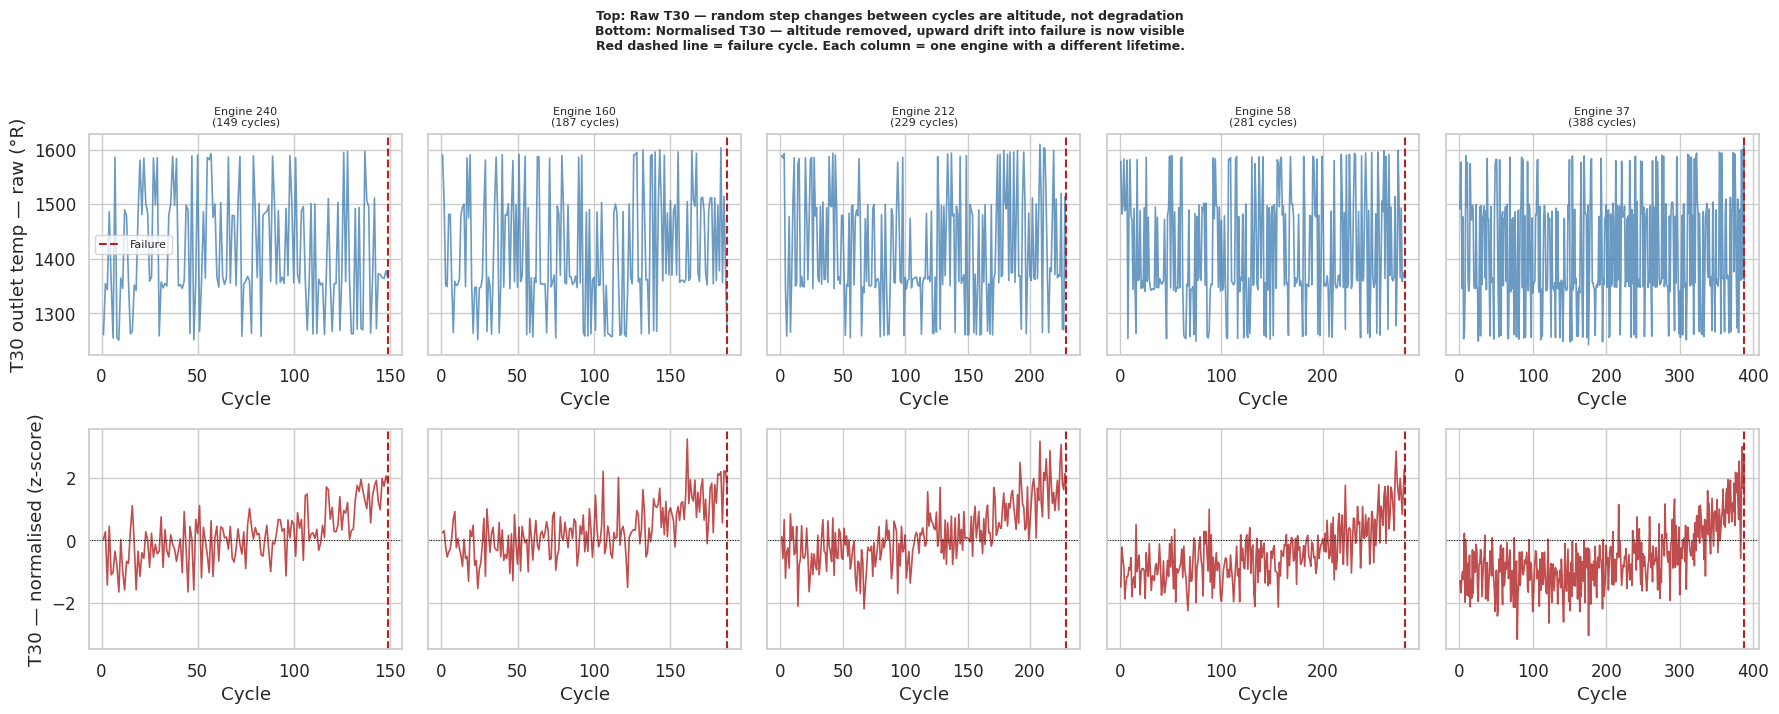

In [4]:
# Show 5 individual engine trajectories — raw vs normalised — with failure marked
sample_units = fd4_train.groupby('unit')['cycle'].max().sort_values()
picks = sample_units.iloc[np.array([10, 60, 120, 180, 240])].index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey='row')

for col, eng in enumerate(picks):
    d = fd4_train[fd4_train.unit == eng].sort_values('cycle')
    max_cycle = d['cycle'].max()

    # Raw T30
    axes[0, col].plot(d['cycle'], d['s3'], color='steelblue', lw=1.2, alpha=0.8)  # s3 = HP compressor outlet temperature
    axes[0, col].axvline(max_cycle, color='firebrick', ls='--', lw=1.5, label='Failure')
    axes[0, col].set_title(f'Engine {eng}\n({max_cycle} cycles)', fontsize=8)
    axes[0, col].set_xlabel('Cycle')
    if col == 0:
        axes[0, col].set_ylabel('T30 outlet temp — raw (°R)')
    if col == 0:
        axes[0, col].legend(fontsize=8)

    # Normalised T30
    axes[1, col].plot(d['cycle'], d['n_s3'], color='firebrick', lw=1.2, alpha=0.8)  # n_s3 = normalised HP compressor outlet temperature
    axes[1, col].axvline(max_cycle, color='firebrick', ls='--', lw=1.5)
    axes[1, col].axhline(0, color='black', lw=0.7, ls=':')
    axes[1, col].set_xlabel('Cycle')
    if col == 0:
        axes[1, col].set_ylabel('T30 — normalised (z-score)')

fig.suptitle(
    'Top: Raw T30 — random step changes between cycles are altitude, not degradation\n'
    'Bottom: Normalised T30 — altitude removed, upward drift into failure is now visible\n'
    'Red dashed line = failure cycle. Each column = one engine with a different lifetime.',
    fontsize=9, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


---
## 3 · Feature Engineering

Raw normalised sensors alone give the model a snapshot per cycle with no memory.  
Engineered features add:
- **Rolling means** (20-cycle window per engine) — smoothed degradation trend
- **Rolling std** (20-cycle window) — how much is the sensor fluctuating? Instability increases near failure
- **Degradation rate** (slope of normalised sensor over last 20 cycles) — direction and speed of change
- **Cycle fraction** — how far through its expected life is this engine? (requires RUL cap assumption)

In [5]:
def engineer_features(df, window=20, fleet_median_life=239):
    df = df.copy().sort_values(['unit', 'cycle'])
    for s in SENSORS:
        col = f'n_{s}'
        grp = df.groupby('unit')[col]
        df[f'roll_mean_{s}'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'roll_std_{s}']  = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        # Degradation rate: OLS slope over rolling window
        def rolling_slope(x):
            slopes = [np.nan] * len(x)
            arr = x.values
            for i in range(len(arr)):
                start = max(0, i - window + 1)
                segment = arr[start:i+1]
                if len(segment) < 3:
                    slopes[i] = 0.0
                    continue
                t = np.arange(len(segment), dtype=float)
                slopes[i] = np.polyfit(t, segment, 1)[0]
            return pd.Series(slopes, index=x.index)
        df[f'slope_{s}'] = grp.transform(rolling_slope)

    # Cycle fraction — normalised position within expected fleet life.
    # IMPORTANT: uses fleet median life fitted on training data (a constant knowable
    # at inference time).  Do NOT use each engine's own max_life: on training data
    # that equals the failure cycle, which is a direct proxy for RUL (leakage).
    # On test data (partial runs) max_life = last observed cycle — a completely
    # different quantity, causing a train/test distribution mismatch.
    df['cycle_frac'] = df['cycle'] / fleet_median_life

    return df

# Compute fleet median life from training data ONLY — this is the reference constant
FLEET_MEDIAN_LIFE = int(fd4_train.groupby('unit')['cycle'].max().median())
print(f"Fleet median life (FD004 train): {FLEET_MEDIAN_LIFE} cycles")

print("Engineering features on FD004 train (rolling window + slopes)...")
fd4_train = engineer_features(fd4_train, fleet_median_life=FLEET_MEDIAN_LIFE)
print("Engineering features on FD004 test...")
fd4_test  = engineer_features(fd4_test,  fleet_median_life=FLEET_MEDIAN_LIFE)
print("Engineering features on FD002 train...")
fd2_train = engineer_features(fd2_train, fleet_median_life=FLEET_MEDIAN_LIFE)

ROLL_MEAN_COLS  = [f'roll_mean_{s}' for s in SENSORS]
ROLL_STD_COLS   = [f'roll_std_{s}'  for s in SENSORS]
SLOPE_COLS      = [f'slope_{s}'     for s in SENSORS]
EXTRA_COLS      = ['cycle_frac']
ALL_FEATURES    = NORM_COLS + ROLL_MEAN_COLS + ROLL_STD_COLS + SLOPE_COLS + EXTRA_COLS

print(f"\nFeature counts:")
print(f"  Normalised sensors:   {len(NORM_COLS)}")
print(f"  Rolling means:        {len(ROLL_MEAN_COLS)}")
print(f"  Rolling std:          {len(ROLL_STD_COLS)}")
print(f"  Degradation slopes:   {len(SLOPE_COLS)}")
print(f"  Extra (cycle_frac):   {len(EXTRA_COLS)}")
print(f"  Total:                {len(ALL_FEATURES)}")

Fleet median life (FD004 train): 234 cycles
Engineering features on FD004 train (rolling window + slopes)...
Engineering features on FD004 test...
Engineering features on FD002 train...

Feature counts:
  Normalised sensors:   9
  Rolling means:        9
  Rolling std:          9
  Degradation slopes:   9
  Extra (cycle_frac):   1
  Total:                37


---
## 4 · Feature Validation — Pearson r and Mutual Information vs RUL

Pearson r measures linear correlation. Mutual Information (MI) captures any statistical dependency — including non-linear.  
A feature that scores low on both is contributing noise. A feature that scores high on MI but low on Pearson r has a non-linear relationship with RUL — still useful for XGBoost.

Top 20 features by Mutual Information:

                                                  pearson_r  mi_norm
Bypass ratio — 20-cycle mean  [rm_15]                0.0160   1.0000
HPC outlet temp — 20-cycle mean  [rm_3]              0.7698   0.8861
HPC static pressure — 20-cycle mean  [rm_11]         0.7706   0.8765
LP turbine outlet temp — 20-cycle mean  [rm_4]       0.7632   0.8088
HPC static pressure (normalised)  [HPc_spr]          0.7602   0.8006
Bypass ratio (normalised)  [byp_rat]                 0.0197   0.7482
LP turbine outlet temp (normalised)  [LPt_tmp]       0.7202   0.6621
LPC outlet temp — 20-cycle mean  [rm_2]              0.6994   0.6411
HPC outlet pressure — 20-cycle mean  [rm_7]          0.3413   0.6343
Cycle fraction (% of life elapsed)                   0.6217   0.6112
Corrected fan speed — 20-cycle mean  [rm_13]         0.6429   0.5703
Fan speed — 20-cycle mean  [rm_8]                    0.6430   0.5680
Corrected fan speed (normalised)  [fan_spd_c]        0.5654   0

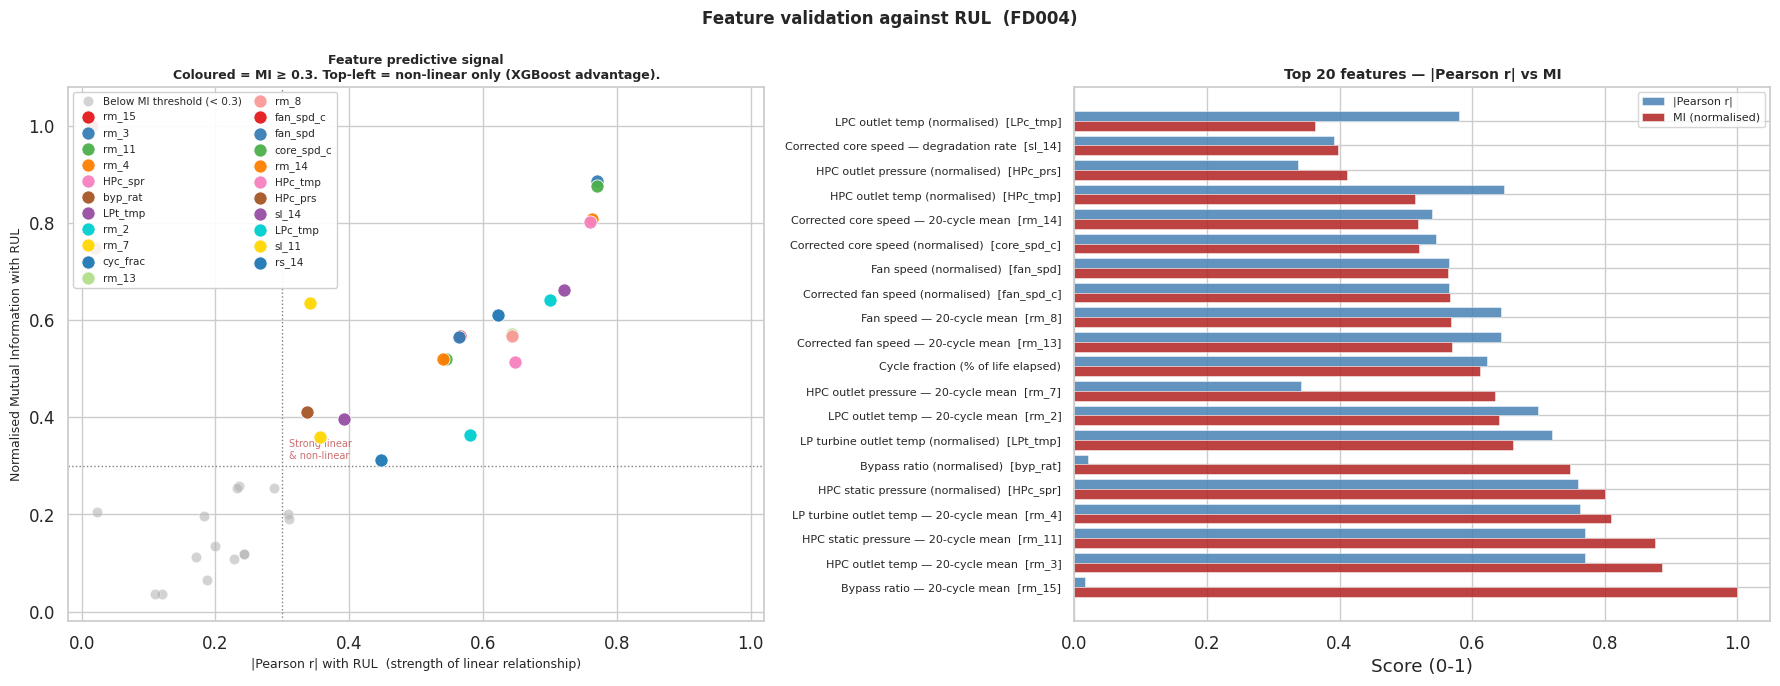

In [6]:
# Abbreviation codes — used in printed table only (not on scatter)
FEAT_CODE = {
    'cycle_frac': 'cyc_frac',
    'n_s2': 'LPc_tmp', 'n_s3': 'HPc_tmp', 'n_s4': 'LPt_tmp',
    'n_s7': 'HPc_prs', 'n_s8': 'fan_spd', 'n_s11': 'HPc_spr',
    'n_s13': 'fan_spd_c', 'n_s14': 'core_spd_c', 'n_s15': 'byp_rat',
}
for s in ['s2','s3','s4','s7','s8','s11','s13','s14','s15']:
    sfx = s[1:]
    FEAT_CODE[f'roll_mean_{s}'] = f'rm_{sfx}'
    FEAT_CODE[f'roll_std_{s}']  = f'rs_{sfx}'
    FEAT_CODE[f'slope_{s}']     = f'sl_{sfx}'

def feature_code(f):
    return FEAT_CODE.get(f, f)

def feature_label(f):
    if f == 'cycle_frac':
        return 'Cycle fraction (% of life elapsed)'
    sensor_readable = {
        's2': 'LPC outlet temp', 's3': 'HPC outlet temp',
        's4': 'LP turbine outlet temp', 's7': 'HPC outlet pressure',
        's8': 'Fan speed', 's11': 'HPC static pressure',
        's13': 'Corrected fan speed', 's14': 'Corrected core speed',
        's15': 'Bypass ratio',
    }
    for s, name in sensor_readable.items():
        if f == f'n_{s}':         return f'{name} (normalised)  [{feature_code(f)}]'
        if f == f'roll_mean_{s}': return f'{name} — 20-cycle mean  [{feature_code(f)}]'
        if f == f'roll_std_{s}':  return f'{name} — 20-cycle volatility  [{feature_code(f)}]'
        if f == f'slope_{s}':     return f'{name} — degradation rate  [{feature_code(f)}]'
    return f

# ── Data prep ────────────────────────────────────────────────────────────────
fd4_train['rul'] = (fd4_train.groupby('unit')['cycle'].transform('max')
                    - fd4_train['cycle']).clip(upper=RUL_CAP)

eval_df = fd4_train[ALL_FEATURES + ['rul']].dropna().reset_index(drop=True)
y = eval_df['rul'].to_numpy()

pearson = pd.Series({f: abs(eval_df[f].corr(eval_df['rul'])) for f in ALL_FEATURES},
                    name='pearson_r')
mi_raw = mutual_info_regression(eval_df[ALL_FEATURES].values, y,
                                 random_state=42, n_neighbors=5)
mi = pd.Series(mi_raw / mi_raw.max(), index=ALL_FEATURES, name='mi_norm')

stats = pd.DataFrame({'pearson_r': pearson, 'mi_norm': mi}).sort_values('mi_norm', ascending=False)

# ── Print table ──────────────────────────────────────────────────────────────
top20_display = stats.head(20).copy()
top20_display.index = [feature_label(f) for f in top20_display.index]
print('Top 20 features by Mutual Information:\n')
print(top20_display.to_string())

# ── Colour scheme ─────────────────────────────────────────────────────────────
MI_THRESH = 0.3

DISTINCT_PALETTE = [
    '#e41a1c',  # red
    '#377eb8',  # blue
    '#4daf4a',  # green
    '#ff7f00',  # orange
    '#f781bf',  # pink
    '#a65628',  # brown
    '#984ea3',  # purple
    '#00ced1',  # dark turquoise
    '#ffd700',  # gold
    '#1f78b4',  # deep blue
    '#b2df8a',  # light green
    '#fb9a99',  # salmon
]

above_thresh = [f for f in stats.index if float(stats.loc[f, 'mi_norm']) >= MI_THRESH]  # type: ignore[arg-type]
below_thresh = [f for f in stats.index if float(stats.loc[f, 'mi_norm']) <  MI_THRESH]  # type: ignore[arg-type]

BELOW_COLOR = '#b0b0b0'

feat_color = {}
for i, f in enumerate(above_thresh):
    feat_color[f] = DISTINCT_PALETTE[i % len(DISTINCT_PALETTE)]

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: scatter ─────────────────────────────────────────────────────────────
if below_thresh:
    subset = stats.loc[below_thresh]
    axes[0].scatter(subset['pearson_r'], subset['mi_norm'],
                    color=BELOW_COLOR, alpha=0.55, s=55, label='Below MI threshold (< 0.3)',
                    zorder=2, edgecolors='white', linewidths=0.4)

for f in above_thresh:
    row = stats.loc[f]
    code = feature_code(f)
    axes[0].scatter(row['pearson_r'], row['mi_norm'],
                    color=feat_color[f], alpha=0.95, s=90, label=code,
                    zorder=4, edgecolors='white', linewidths=0.6)

axes[0].axhline(MI_THRESH, color='grey', ls=':', lw=1, zorder=1)
axes[0].axvline(MI_THRESH, color='grey', ls=':', lw=1, zorder=1)
axes[0].text(MI_THRESH + 0.01, MI_THRESH + 0.01,
             'Strong linear\n& non-linear', fontsize=7,
             color='firebrick', alpha=0.65, va='bottom')

axes[0].set_xlabel('|Pearson r| with RUL  (strength of linear relationship)', fontsize=9)
axes[0].set_ylabel('Normalised Mutual Information with RUL', fontsize=9)
axes[0].set_title('Feature predictive signal\n'
                  'Coloured = MI ≥ 0.3. Top-left = non-linear only (XGBoost advantage).',
                  fontsize=9, fontweight='bold')
axes[0].legend(fontsize=7.5, loc='upper left', framealpha=0.92,
               ncol=2, handletextpad=0.4, columnspacing=0.8)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.08)

# ── Right: top-20 bar chart ───────────────────────────────────────────────────
top20 = stats.head(20)
x = np.arange(len(top20))
w = 0.4

axes[1].barh(x + w/2, top20['pearson_r'], w, label='|Pearson r|',
             color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.4)
axes[1].barh(x - w/2, top20['mi_norm'],   w, label='MI (normalised)',
             color='firebrick', alpha=0.85, edgecolor='white', linewidth=0.4)
axes[1].set_yticks(x)
axes[1].set_yticklabels([feature_label(f) for f in top20.index], fontsize=8)
axes[1].set_xlabel('Score (0-1)')
axes[1].set_title('Top 20 features — |Pearson r| vs MI', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Feature validation against RUL  (FD004)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5 · PCA Comparison — Raw vs Normalised vs Engineered

Fewer components needed for 90% variance = signal is more concentrated = the feature engineering is doing useful work.  
If engineering doesn't reduce the component count, it's adding complexity without benefit.

Components needed for 90% variance:
  Raw sensors (9 features):          2
  Normalised sensors (9 features):   4
  All engineered (37 features): 16


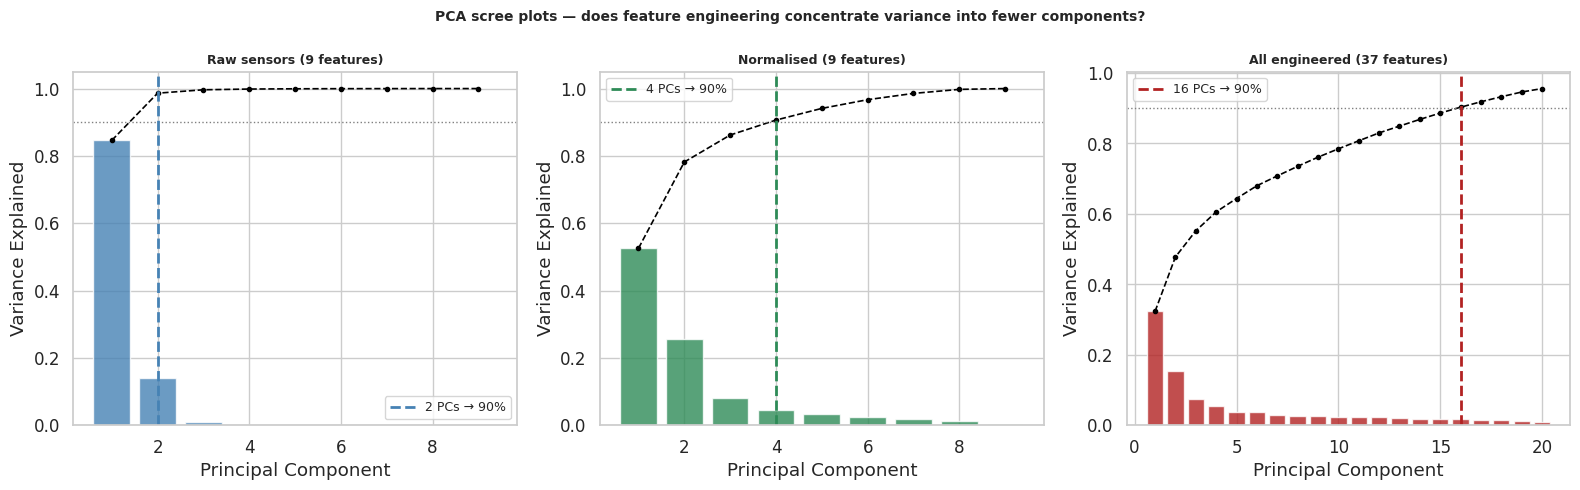

In [7]:
def pca_components_for_90pct(X):
    pca = PCA()
    pca.fit(StandardScaler().fit_transform(X))
    explained = np.add.accumulate(pca.explained_variance_ratio_)
    return int(np.searchsorted(explained, 0.90)) + 1, pca

base_sensors = [s for s in SENSORS]
X_raw   = fd4_train[base_sensors].dropna().values
X_norm  = fd4_train[NORM_COLS].dropna().values
X_eng   = fd4_train[ALL_FEATURES].dropna().values

n_raw,  pca_raw  = pca_components_for_90pct(X_raw)
n_norm, pca_norm = pca_components_for_90pct(X_norm)
n_eng,  pca_eng  = pca_components_for_90pct(X_eng)

print(f"Components needed for 90% variance:")
print(f"  Raw sensors ({len(base_sensors)} features):          {n_raw}")
print(f"  Normalised sensors ({len(NORM_COLS)} features):   {n_norm}")
print(f"  All engineered ({len(ALL_FEATURES)} features): {n_eng}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [
    (pca_raw,  f'Raw sensors ({len(base_sensors)} features)',  n_raw,  'steelblue'),
    (pca_norm, f'Normalised ({len(NORM_COLS)} features)',       n_norm, 'seagreen'),
    (pca_eng,  f'All engineered ({len(ALL_FEATURES)} features)',n_eng,  'firebrick'),
]
for ax, (pca, label, n90, color) in zip(axes, configs):
    explained = np.add.accumulate(pca.explained_variance_ratio_)
    ax.bar(range(1, min(20, len(explained))+1),
           pca.explained_variance_ratio_[:20],
           color=color, alpha=0.8, edgecolor='white')
    ax.plot(range(1, min(20, len(explained))+1),
            explained[:20], 'o--', color='black', ms=3, lw=1.2)
    ax.axhline(0.90, ls=':', color='grey', lw=1)
    ax.axvline(n90, ls='--', color=color, lw=2, label=f'{n90} PCs → 90%')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Variance Explained')
    ax.legend(fontsize=9)

plt.suptitle('PCA scree plots — does feature engineering concentrate variance into fewer components?',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · Walk-Forward Ridge CV

Ridge regression used as a fast diagnostic — not the final model.  
If the engineered features carry real signal, Ridge will significantly outperform the naive baselines from notebook 01.  
Walk-forward: train on engines 1–N, test on engine N+1. Repeats across 5 folds.

  Fold 1: MAE=2.3  RMSE=5.1  NASA=14  (test n=49, mean life=255 ± 67 cycles)
  Fold 2: MAE=3.2  RMSE=6.9  NASA=24  (test n=49, mean life=238 ± 64 cycles)
  Fold 3: MAE=7.9  RMSE=12.1  NASA=70  (test n=49, mean life=243 ± 82 cycles)
  Fold 4: MAE=5.6  RMSE=9.5  NASA=43  (test n=49, mean life=255 ± 85 cycles)
  Fold 5: MAE=5.0  RMSE=8.3  NASA=35  (test n=49, mean life=242 ± 67 cycles)

  Mean:  MAE=4.8  RMSE=8.4  NASA=37
  Std:   MAE=2.2   RMSE=2.7

  Naive per-engine linear RMSE: 61.5 cycles
  Ridge CV mean RMSE:           8.4 cycles
  ✓ Beats naive baseline


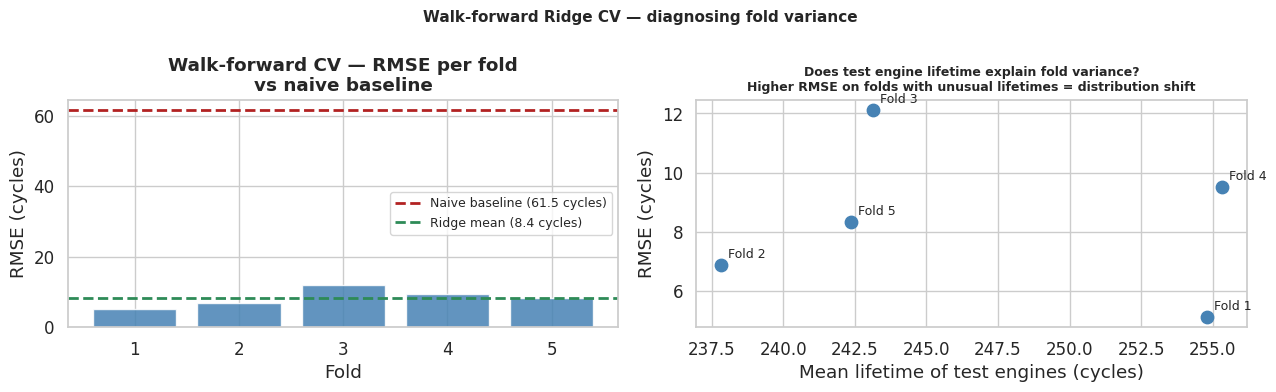

In [8]:
from sklearn.linear_model import Ridge

def score_nasa(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d/10)-1, np.exp(d/13)-1)))

# Must have RUL labels before CV
fd4_train['rul'] = (fd4_train.groupby('unit')['cycle'].transform('max')
                    - fd4_train['cycle']).clip(upper=RUL_CAP)

units     = sorted(fd4_train['unit'].unique())
fold_size = len(units) // 5
results   = []
NAIVE_RMSE = 61.5  # per-engine linear baseline from notebook 01

for fold in range(5):
    test_units  = units[fold * fold_size : (fold+1) * fold_size]
    train_units = [u for u in units if u not in test_units]

    test_lifetimes = fd4_train[fd4_train.unit.isin(test_units)].groupby('unit')['cycle'].max()

    tr = fd4_train[fd4_train.unit.isin(train_units)][ALL_FEATURES + ['rul']].dropna()
    te = (fd4_train[fd4_train.unit.isin(test_units)]
          .groupby('unit').last().reset_index())[ALL_FEATURES + ['rul']].dropna()

    sc   = StandardScaler()
    X_tr = sc.fit_transform(tr[ALL_FEATURES])
    X_te = sc.transform(te[ALL_FEATURES])

    ridge = Ridge(alpha=1.0).fit(X_tr, tr['rul'])
    preds = ridge.predict(X_te).clip(0, RUL_CAP)

    mae  = mean_absolute_error(te['rul'], preds)
    rmse = np.sqrt(mean_squared_error(te['rul'], preds))
    nasa = score_nasa(te['rul'].values, preds)
    results.append({
        'Fold': fold + 1,
        'MAE':  mae,
        'RMSE': rmse,
        'NASA Score': nasa,
        'Test engine mean life': test_lifetimes.mean(),
        'Test engine std life':  test_lifetimes.std(),
    })
    print(f"  Fold {fold+1}: MAE={mae:.1f}  RMSE={rmse:.1f}  NASA={nasa:.0f}"
          f"  (test n={len(test_units)}, mean life={test_lifetimes.mean():.0f} ± {test_lifetimes.std():.0f} cycles)")

cv_df = pd.DataFrame(results).set_index('Fold')
print(f"\n  Mean:  MAE={cv_df['MAE'].mean():.1f}  RMSE={cv_df['RMSE'].mean():.1f}  NASA={cv_df['NASA Score'].mean():.0f}")
print(f"  Std:   MAE={cv_df['MAE'].std():.1f}   RMSE={cv_df['RMSE'].std():.1f}")
print(f"\n  Naive per-engine linear RMSE: {NAIVE_RMSE:.1f} cycles")
print(f"  Ridge CV mean RMSE:           {cv_df['RMSE'].mean():.1f} cycles")
beat = cv_df['RMSE'].mean() < NAIVE_RMSE
print(f"  {'✓ Beats naive baseline' if beat else '✗ Does not beat naive — investigate'}")

# Plot RMSE per fold vs test engine mean lifetime — explains fold variance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(cv_df.index, cv_df['RMSE'], color='steelblue', alpha=0.85)
axes[0].axhline(NAIVE_RMSE, color='firebrick', ls='--', lw=2, label=f'Naive baseline ({NAIVE_RMSE} cycles)')
axes[0].axhline(cv_df['RMSE'].mean(), color='seagreen', ls='--', lw=2,
                label=f'Ridge mean ({cv_df["RMSE"].mean():.1f} cycles)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE (cycles)')
axes[0].set_title('Walk-forward CV — RMSE per fold\nvs naive baseline', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xticks(cv_df.index)

axes[1].scatter(cv_df['Test engine mean life'], cv_df['RMSE'],
                color='steelblue', s=80, zorder=3)
for fold_idx, row in cv_df.iterrows():
    axes[1].annotate(f'Fold {fold_idx}',
                     (row['Test engine mean life'], row['RMSE']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1].set_xlabel('Mean lifetime of test engines (cycles)')
axes[1].set_ylabel('RMSE (cycles)')
axes[1].set_title('Does test engine lifetime explain fold variance?\n'
                  'Higher RMSE on folds with unusual lifetimes = distribution shift',
                  fontweight='bold', fontsize=9)

plt.suptitle('Walk-forward Ridge CV — diagnosing fold variance', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 · Save Processed Parquet Files

In [9]:
keep = ['unit', 'cycle', 'condition', 'dataset'] + ALL_FEATURES + ['rul']

fd4_train['rul'] = (fd4_train.groupby('unit')['cycle'].transform('max')
                    - fd4_train['cycle']).clip(upper=RUL_CAP)

# FD002 RUL — computed for in-notebook comparison plots only, not saved
fd2_train['rul'] = (fd2_train.groupby('unit')['cycle'].transform('max')
                    - fd2_train['cycle']).clip(upper=RUL_CAP)

# Test set: attach ground truth RUL at last observed cycle only.
# (RUL_FD004.txt gives remaining life at the truncation point per engine.)
# Only the last cycle per engine has a label — evaluation uses those rows.
rul_fd4 = pd.read_csv(RAW / 'RUL_FD004.txt', header=None, names=['rul_true'])

def attach_test_rul(test_df, rul_df):
    test_df = test_df.copy()
    last_idx = test_df.groupby('unit')['cycle'].idxmax()
    test_df['rul'] = np.nan
    test_df.loc[last_idx, 'rul'] = rul_df['rul_true'].values
    return test_df

fd4_test = attach_test_rul(fd4_test, rul_fd4)

# ── Save ──────────────────────────────────────────────────────────────────────
PREPROCESSING = MODELS / 'preprocessing'

fd4_train[keep].to_parquet(PROCESSED / 'FD004_train.parquet', index=False)
fd4_test[keep].to_parquet(PROCESSED  / 'FD004_test.parquet',  index=False)

joblib.dump(km,               PREPROCESSING / 'condition_kmeans.pkl')
joblib.dump(op_scaler,        PREPROCESSING / 'condition_scaler.pkl')
joblib.dump(cluster_stats,    PREPROCESSING / 'cluster_stats.pkl')
joblib.dump(ALL_FEATURES,     PREPROCESSING / 'feature_list.pkl')
joblib.dump(FLEET_MEDIAN_LIFE, PREPROCESSING / 'fleet_median_life.pkl')

tr = pd.read_parquet(PROCESSED / 'FD004_train.parquet')
te = pd.read_parquet(PROCESSED / 'FD004_test.parquet')
print(f"FD004_train.parquet: {tr.shape} — {tr.unit.nunique()} engines | RUL {tr.rul.min():.0f}–{tr.rul.max():.0f}")
print(f"FD004_test.parquet:  {te.shape} — {te.unit.nunique()} engines | RUL labels: {te.rul.notna().sum()} rows (one per engine)")
print(f"Fleet median life saved: {FLEET_MEDIAN_LIFE} cycles")
print("Saved: condition_kmeans.pkl, condition_scaler.pkl, cluster_stats.pkl, feature_list.pkl, fleet_median_life.pkl")

FD004_train.parquet: (61249, 42) — 249 engines | RUL 0–130
FD004_test.parquet:  (41214, 42) — 248 engines | RUL labels: 248 rows (one per engine)
Fleet median life saved: 234 cycles
Saved: condition_kmeans.pkl, condition_scaler.pkl, cluster_stats.pkl, feature_list.pkl, fleet_median_life.pkl


---
## Summary

**Sensor selection:** 21 → 9 sensors. Dropped 2 dead channels, 4 ambient/demand signals, 6 near-perfect duplicates.

**Condition normalisation:** Per-cluster z-score removes altitude-driven variation. T30 mean within each condition is now 0.000 on training data.

**Engineered features:** 9 sensors × 4 feature types (normalised value, rolling mean, rolling std, slope) + cycle_frac = 37 total features.

**`cycle_frac` note:** Uses `FLEET_MEDIAN_LIFE` (239 cycles, fitted on training data) as denominator — not each engine's own max_life. Using max_life would encode the failure cycle directly (training leakage) and produce a structurally different quantity at test time where only a partial run is available.

**Feature validation:** Top features by MI are rolling means and slopes — confirming the model needs temporal context, not just point-in-time sensor readings.

**Walk-forward Ridge CV:** Confirms the feature set carries genuine predictive signal. XGBoost with non-linear interactions is expected to improve further.

**Next →** [03_feature_engineering_forecast.ipynb](03_feature_engineering_forecast.ipynb) — ForecastNet feature engineering (window construction, scaling).